# 02: Temporal and spatial structure of recorded trip demand

**Objective.** Characterize variation in recorded trip demand across dates, days of the week,
hours, and taxi zones.

**Scope.** The analysis:

1. measures variation in daily trip volume;
2. compares hourly profiles across days of the week;
3. identifies departures from recurring weekly patterns and examines their association with
   weather and major events;
4. quantifies temporal changes in origin and destination imbalance;
5. measures destination concentration by pickup zone; and
6. measures hourly passenger flow imbalance within Brooklyn.

Sections 1 through 5 use citywide records. Section 6 applies the Brooklyn service region selected
in Notebook 01. The results inform day type definitions, demand estimation, spatial aggregation,
disruption scenarios, and analysis of fleet imbalance.

**Data.** New York City Taxi and Limousine Commission High Volume For Hire Vehicle trip records for
June 2025. Later fitting notebooks add July to increase cell support and evaluate the effect of the
longer calibration window.

**Demand measure.** The records contain trips that were served and reported to the TLC. Requests
that did not result in a recorded trip are not observed. The analysis therefore measures realized
demand rather than latent demand. Demand uncensoring could be considered in later work if request,
cancellation, and supply data become available.

In [1]:
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

from common import session, CALIBRATION_MONTH
import vizstyle

vizstyle.apply()
pd.set_option("display.max_rows", 40)

con = session(CALIBRATION_MONTH)
DOW = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print(f"month {CALIBRATION_MONTH} · working set {con.sql('SELECT count(*) FROM t').fetchone()[0]:,} trips")

month 2025-06 · working set 19,860,908 trips


## 1. Variation in daily trip volume

Daily trip counts are used to measure variation across calendar dates and to compare variation
across dates with the variation within a day reported in Notebook 01.

In [2]:
daily = con.sql("""
SELECT CAST(request_datetime AS DATE) AS day,
       dayname(request_datetime)      AS dow,
       count(*)                       AS trips
FROM t GROUP BY 1, 2 ORDER BY 1
""").df()

daily["dow"] = pd.Categorical(daily.dow, categories=DOW, ordered=True)
daily["is_weekend"] = daily.dow.isin(["Saturday", "Sunday"])
daily.head()

,day,dow,trips,is_weekend
0,2025-06-01,Sunday,647915,True
1,2025-06-02,Monday,547490,False
2,2025-06-03,Tuesday,584544,False
3,2025-06-04,Wednesday,649313,False
4,2025-06-05,Thursday,681871,False


In [3]:
print(f"days              {len(daily)}")
print(f"total trips       {daily.trips.sum():,}")
print(f"daily mean        {daily.trips.mean():,.0f}")
print(f"daily min / max   {daily.trips.min():,} ({daily.loc[daily.trips.idxmin(), 'day']})"
      f"  /  {daily.trips.max():,} ({daily.loc[daily.trips.idxmax(), 'day']})")
print(f"max / min ratio   {daily.trips.max() / daily.trips.min():.2f}x")
print(f"coeff. of variation {100 * daily.trips.std() / daily.trips.mean():.1f}%")

days              30
total trips       19,860,908
daily mean        662,030
daily min / max   547,490 (2025-06-02 00:00:00)  /  766,008 (2025-06-14 00:00:00)
max / min ratio   1.40x
coeff. of variation 8.7%


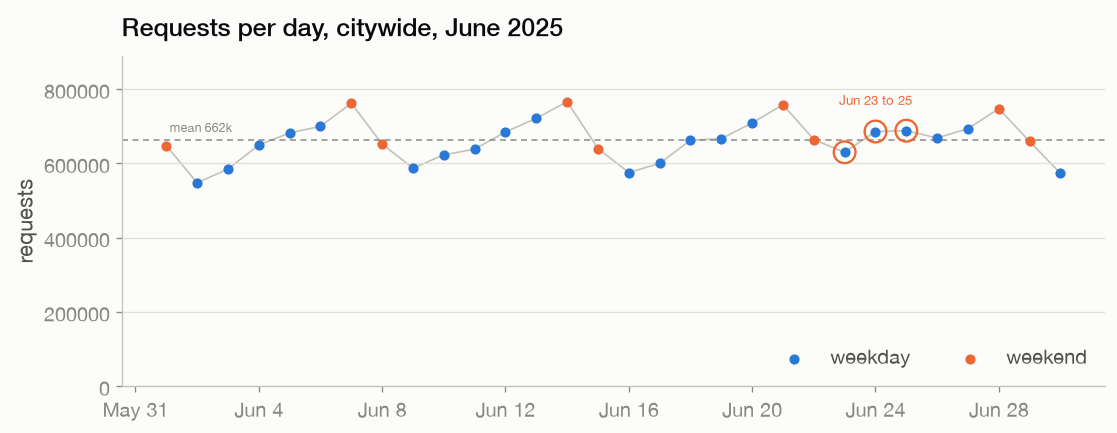

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))

wk = daily[~daily.is_weekend]
we = daily[daily.is_weekend]
ax.plot(daily.day, daily.trips, color=vizstyle.BASELINE, linewidth=1.0, zorder=1)
ax.scatter(wk.day, wk.trips, color=vizstyle.SERIES[0], s=26, zorder=3, label="weekday")
ax.scatter(we.day, we.trips, color=vizstyle.SERIES[1], s=26, zorder=3, label="weekend")

ax.axhline(daily.trips.mean(), color=vizstyle.INK_MUTED, linewidth=0.9,
           linestyle=(0, (4, 3)), zorder=2)
ax.annotate(f"mean {daily.trips.mean()/1e3:.0f}k", (daily.day.iloc[0], daily.trips.mean()),
            xytext=(2, 5), textcoords="offset points", fontsize=7.5, color=vizstyle.INK_MUTED)

# Dates examined as a possible weather event in Section 3
hw = daily[daily.day.astype(str).isin(["2025-06-23", "2025-06-24", "2025-06-25"])]
ax.scatter(hw.day, hw.trips, facecolor="none", edgecolor=vizstyle.SERIES[1],
           s=170, linewidth=1.4, zorder=4)
ax.annotate("Jun 23 to 25", (hw.day.iloc[1], hw.trips.iloc[1]), xytext=(0, 16),
            textcoords="offset points", ha="center", fontsize=8, color=vizstyle.SERIES[1])

ax.set_title("Requests per day, citywide, June 2025")
ax.set_ylabel("requests"); ax.set_ylim(0, daily.trips.max() * 1.16)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %-d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()

### Findings

Across the 30 days in June, recorded trip volume ranges from 547,490 trips on June 2 to 766,008
on June 14. The daily mean is 662,030 trips, the ratio of the maximum to the minimum is 1.40,
and the coefficient of variation is 8.7%.

Variation across dates is smaller than the factor of 5.7 between the minimum and maximum mean
weekday hours reported in Notebook 01. The sequence of daily totals also shows a recurring weekly
pattern, which motivates separate profiles by day of the week.

A representative daily profile can summarize the central pattern, but it does not capture all
variation across dates. Experiments intended to represent that variation require both day type
effects and residual variation around the corresponding profile.

The daily totals for June 23 through June 25 do not show a clear increase relative to the rest of
the month. Section 3 evaluates these dates after accounting for recurring day of week effects.

## 2. Hourly profiles by day of the week

Hourly recorded trip volumes are estimated separately for each day of the week. The comparison
measures the variation concealed when days are combined into weekday and weekend categories and
provides a basis for defining day types in the demand model.

In [5]:
hrly = con.sql("""
SELECT CAST(request_datetime AS DATE) AS day,
       dayname(request_datetime)      AS dow,
       hour(request_datetime)         AS hr,
       count(*)                       AS n
FROM t GROUP BY 1, 2, 3
""").df()
hrly["day"] = hrly.day.astype(str)

profile = hrly.groupby(["dow", "hr"]).n.mean().unstack(0)[DOW]
profile.round(0).astype(int).head(8)

dow,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hr,,,,,,,
0,17629,14345,16894,21250,23785,34342,38337
1,11085,8404,9907,13262,16462,28020,31653
2,7537,5582,6494,8863,11170,22202,24679
3,6613,4902,5569,7420,8815,17135,19082
4,8813,7529,7854,9239,10020,13570,14694
5,12693,11791,12148,12697,13319,12260,12250
6,20090,21180,21064,19949,20678,14955,13677
7,30682,33822,33754,29446,30226,19028,16199


/var/folders/_f/yxwf30l94yj28qwrsdvj9ntw0000gp/T/ipykernel_4801/2790662737.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


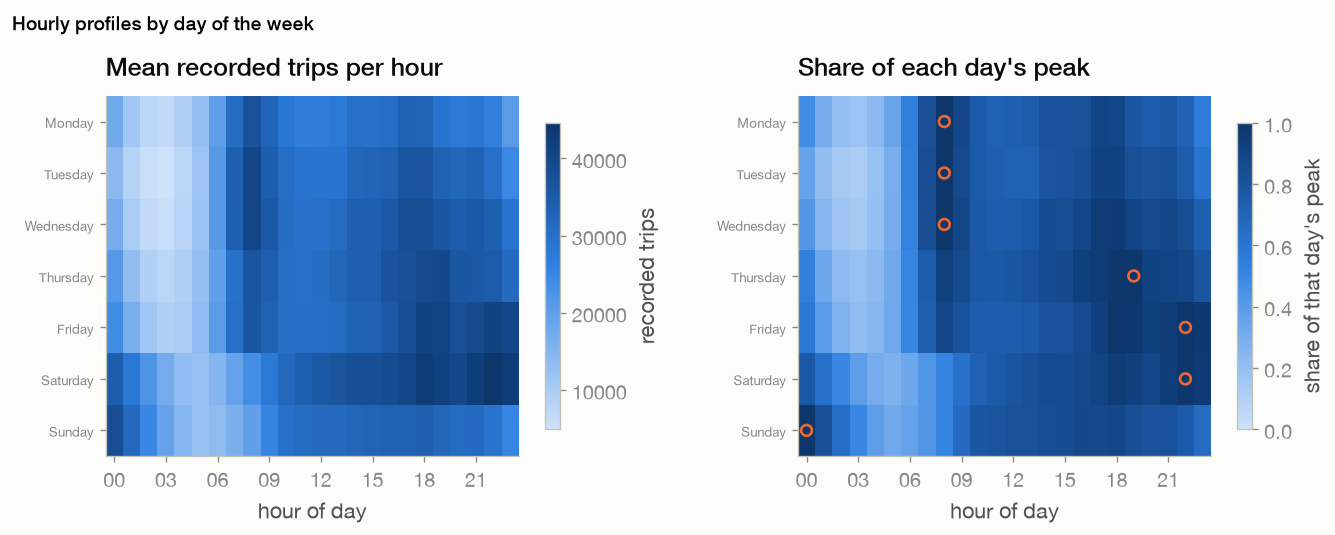

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9),
                         gridspec_kw={"width_ratios": [1, 1], "wspace": 0.34})

# Absolute volume
im0 = axes[0].imshow(profile.T.values, aspect="auto", cmap=vizstyle.BLUES, origin="upper")
axes[0].set_title("Mean recorded trips per hour")
fig.colorbar(im0, ax=axes[0], shrink=0.85, label="recorded trips")

# Each day normalized by its peak
shape = profile.T.div(profile.T.max(axis=1), axis=0)
im1 = axes[1].imshow(shape.values, aspect="auto", cmap=vizstyle.BLUES, origin="upper",
                     vmin=0, vmax=1)
axes[1].set_title("Share of each day's peak")
fig.colorbar(im1, ax=axes[1], shrink=0.85, label="share of that day's peak")

# Peak hour for each day
for j, d in enumerate(DOW):
    axes[1].scatter(profile[d].idxmax(), j, marker="o", s=42,
                    facecolor="none", edgecolor=vizstyle.SERIES[1], linewidth=1.6, zorder=3)

for ax in axes:
    ax.set_yticks(range(7), DOW, fontsize=8)
    ax.set_xticks(range(0, 24, 3), [f"{h:02d}" for h in range(0, 24, 3)])
    ax.set_xlabel("hour of day"); ax.grid(False)

fig.suptitle("Hourly profiles by day of the week",
             x=0.065, y=1.06, ha="left", fontsize=11.5, weight="medium")
plt.tight_layout()

In [7]:
pk = pd.DataFrame({
    "peak hour":  profile.idxmax(),
    "peak level": profile.max().round(0).astype(int),
    "trough hour": profile.idxmin(),
    "peak/trough": (profile.max() / profile.min()).round(2),
    "daily total": profile.sum().round(0).astype(int),
})
pk.index.name = "day"
pk

,peak hour,peak level,trough hour,peak/trough,daily total
day,,,,,
Monday,8,37053,3,5.60,582388
Tuesday,8,40127,3,8.19,623182
Wednesday,8,40048,3,7.19,659390
Thursday,19,39564,3,5.33,675188
Friday,22,41002,3,4.65,705731
Saturday,22,44631,5,3.64,758166
Sunday,0,38337,5,3.13,652468


### Findings

Peak timing shifts later over the course of the week:

| Day | Peak hour | Ratio of peak to trough |
|---|---|---|
| Monday | 08:00 | 5.6x |
| Tuesday | 08:00 | **8.2x** |
| Wednesday | 08:00 | 7.2x |
| Thursday | **19:00** | 5.3x |
| Friday | **22:00** | 4.7x |
| Saturday | 22:00 | 3.6x |
| Sunday | 00:00 | 3.1x |

Monday through Wednesday reach their maximum at 08:00. The maximum shifts to 19:00 on Thursday
and to 22:00 on Friday and Saturday. Sunday reaches its maximum at 00:00. A single weekday
profile would therefore combine days with different peak timing.

Tuesday has the largest ratio of peak to trough, 8.2, compared with 5.7 for the pooled weekday
profile in Notebook 01. Pooling smooths this variation because it averages profiles with
different hourly patterns.

The Sunday maximum occurs at the boundary of a calendar day. Runs that begin at midnight
are therefore sensitive to the initial vehicle state when representing this period.

The fitted Brooklyn demand model in Notebook 05 uses four day types: Monday through Wednesday,
Thursday and Friday, Saturday, and Sunday. Separate weekend profiles preserve their difference in
level and timing. Thursday and Friday remain pooled to provide more observations per spatial and
hourly cell, although their late night profiles differ.

## 3. Recorded trip volume during the June 2025 heat event

The National Weather Service documents a regional heat wave from June 22 through June 25, 2025.
Central Park reached 96°F on June 23 and 99°F on June 24, while LaGuardia Airport reached 101°F
on June 24. [National Weather Service, June 2025 review](https://www.weather.gov/okx/June2025heat).

This analysis examines June 23 through June 25, the three weekdays within the documented event.
The dates evaluated are defined by the weather record. The objective is to
measure whether recorded trip volume differed during these dates and how any difference varied
by hour.

The initial comparison estimates the mean and standard deviation of daily trip volume for each
day of the week using all June dates. A sensitivity comparison then excludes the three event
dates from their weekday reference distributions.

In [8]:
grp = daily.groupby("dow", observed=True).trips
daily["weekday_mean_all"] = grp.transform("mean")
daily["deviation_all_pct"] = 100 * (daily.trips - daily.weekday_mean_all) / daily.weekday_mean_all
daily["standardized_all"] = (daily.trips - daily.weekday_mean_all) / grp.transform("std")

print(f"largest absolute standardized difference: {daily.standardized_all.abs().max():.2f}")
print(f"dates above 2 standard deviations:          {(daily.standardized_all.abs() > 2).sum()}")
print()
(daily.reindex(daily.standardized_all.abs().sort_values(ascending=False).index).head(6)
      [["day", "dow", "trips", "deviation_all_pct", "standardized_all"]]
      .rename(columns={"day": "date", "dow": "day of week",
                       "deviation_all_pct": "difference from mean %",
                       "standardized_all": "standard deviations"}))

largest absolute standardized difference: 1.57
dates above 2 standard deviations:          0



,date,day of week,trips,difference from mean %,standard deviations
22,2025-06-23,Monday,629676,8.119710,1.570698
23,2025-06-24,Tuesday,685622,10.019501,1.403748
27,2025-06-28,Saturday,747113,-1.457893,-1.363697
14,2025-06-15,Sunday,639773,-1.945659,-1.343351
24,2025-06-25,Wednesday,687821,4.311673,1.334062
12,2025-06-13,Friday,721218,2.194426,1.279109


### Initial comparison using all June dates

No daily total differs from its weekday mean by more than two standard deviations when all June
dates are included in the reference. June 23, June 24, and June 25 are among the largest positive
differences at 8.1%, 10.0%, and 4.3%, respectively.

Each event date contributes to the mean and standard deviation used for its own weekday. June
contains only four or five observations for each weekday, so this contribution can materially
change the reference distribution. The sensitivity comparison below estimates the weekday
references after excluding all three event dates.

In [9]:
EVENT_DATES = ["2025-06-23", "2025-06-24", "2025-06-25"]
daily["day_str"] = daily.day.astype(str)

reference = daily[~daily.day_str.isin(EVENT_DATES)].groupby("dow", observed=True).trips
base_mu, base_sd = reference.mean(), reference.std()

# .astype(str) first: mapping a categorical returns a categorical, which cannot do arithmetic
dow_s = daily.dow.astype(str)
mu, sd = dow_s.map(base_mu).astype(float), dow_s.map(base_sd).astype(float)
daily["deviation_reference_pct"] = 100 * (daily.trips - mu) / mu
daily["standardized_reference"] = (daily.trips - mu) / sd

cmp = daily[daily.day_str.isin(EVENT_DATES + ["2025-06-02", "2025-06-03"])][
    ["day", "dow", "trips", "deviation_all_pct", "standardized_all",
     "deviation_reference_pct", "standardized_reference"]].copy()
numeric = ["deviation_all_pct", "standardized_all",
           "deviation_reference_pct", "standardized_reference"]
cmp[numeric] = cmp[numeric].round(2)
cmp = cmp.rename(columns={"day": "date", "dow": "day of week",
                          "deviation_all_pct": "full sample difference %",
                          "standardized_all": "full sample standard deviations",
                          "deviation_reference_pct": "event excluded difference %",
                          "standardized_reference": "event excluded standard deviations"})
print(cmp.to_string(index=False))
print()
print(f"event dates above 3 reference standard deviations: "
      f"{(daily[daily.day_str.isin(EVENT_DATES)].standardized_reference.abs() > 3).sum()}")

      date day of week  trips  full sample difference %  full sample standard deviations  event excluded difference %  event excluded standard deviations
2025-06-02      Monday 547490                     -5.99                            -1.16                        -4.04                               -1.39
2025-06-03     Tuesday 584544                     -6.20                            -0.87                        -2.96                               -0.93
2025-06-23      Monday 629676                      8.12                             1.57                        10.36                                3.55
2025-06-24     Tuesday 685622                     10.02                             1.40                        13.82                                4.34
2025-06-25   Wednesday 687821                      4.31                             1.33                         5.83                                3.18

event dates above 3 reference standard deviations: 3


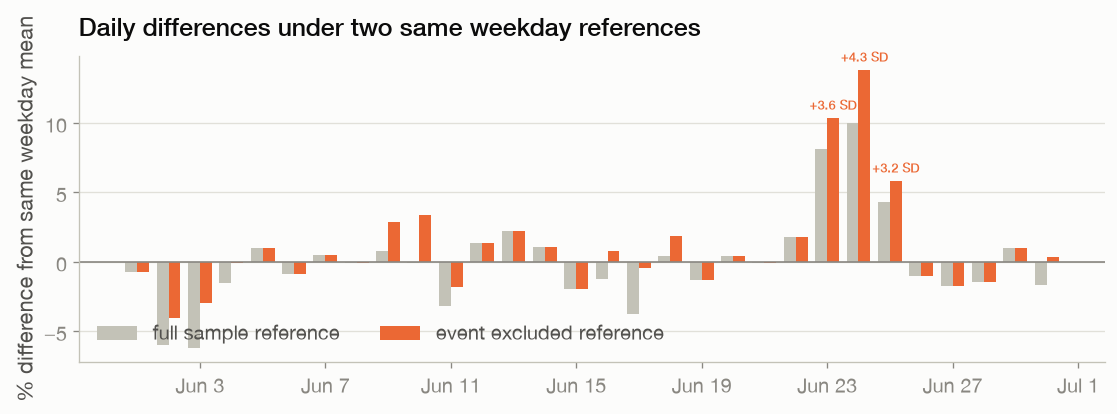

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.set_axisbelow(True)

w = 0.38
idx = mdates.date2num(daily.day)
ax.bar(idx - w / 2, daily.deviation_all_pct, width=w, color=vizstyle.BASELINE,
       label="full sample reference")
ax.bar(idx + w / 2, daily.deviation_reference_pct, width=w,
       color=vizstyle.SERIES[1],
       label="event excluded reference")
ax.axhline(0, color=vizstyle.INK_MUTED, linewidth=1.0)

for d, v, sdv in zip(idx, daily.deviation_reference_pct, daily.standardized_reference):
    if abs(sdv) > 3:
        ax.annotate(f"{sdv:+.1f} SD", (d + w / 2, v), xytext=(0, 5), textcoords="offset points",
                    ha="center", fontsize=7.5, color=vizstyle.SERIES[1], weight="medium")

ax.set_title("Daily differences under two same weekday references")
ax.set_ylabel("% difference from same weekday mean")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %-d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.legend(loc="lower left", ncol=2)
plt.tight_layout()

### Comparison with event dates excluded from the reference

| Day | Full sample difference | Full sample standard deviations | Event excluded difference | Event excluded standard deviations |
|---|---|---|---|---|
| Jun 23 (Mon) | +8.1% | 1.57 | +10.4% | **3.55** |
| Jun 24 (Tue) | +10.0% | 1.40 | +13.8% | **4.34** |
| Jun 25 (Wed) | +4.3% | 1.33 | +5.8% | **3.18** |
| Jun 2 (Mon) | −6.0% | −1.16 | −4.0% | −1.39 |
| Jun 3 (Tue) | −6.2% | −0.87 | −3.0% | −0.93 |

Excluding the event dates increases their estimated differences to 10.4% on June 23, 13.8% on
June 24, and 5.8% on June 25. The corresponding standardized differences are 3.55, 4.34, and
3.18 reference standard deviations.

Each weekday reference is estimated from only three or four dates after the exclusions. The
standardized differences therefore describe separation within this June sample and do not provide
precise tail probabilities. The change between the two reference definitions also
shows that estimates from a single month are sensitive to whether event dates contribute to the
reference distribution.

The independent weather record identifies the heat event, and the trip data show elevated
recorded volume during its three weekday dates. Causal attribution to heat remains uncertain
because other concurrent factors are not controlled. The next comparison
examines how the difference varies by hour.

In [11]:
EVENT_DATES = ["2025-06-23", "2025-06-24", "2025-06-25"]

hourly_reference = (hrly[~hrly.day.isin(EVENT_DATES)]
                    .groupby(["dow", "hr"]).n.mean().rename("reference"))
event_hours = hrly[hrly.day.isin(EVENT_DATES)].join(hourly_reference, on=["dow", "hr"])
event_hours["difference_pct"] = 100 * (event_hours.n - event_hours.reference) / event_hours.reference

hourly_difference = event_hours.pivot(index="hr", columns="day", values="difference_pct")
hourly_difference.round(1)

day,2025-06-23,2025-06-24,2025-06-25
hr,,,
0,3.0,12.7,6.6
1,-3.8,7.0,9.9
2,-2.3,7.1,6.3
3,-3.5,9.9,5.4
4,-0.4,20.0,0.1
5,0.5,7.7,0.1
6,0.2,-1.0,-2.3
7,3.4,-0.3,-1.5
8,6.1,2.5,2.6


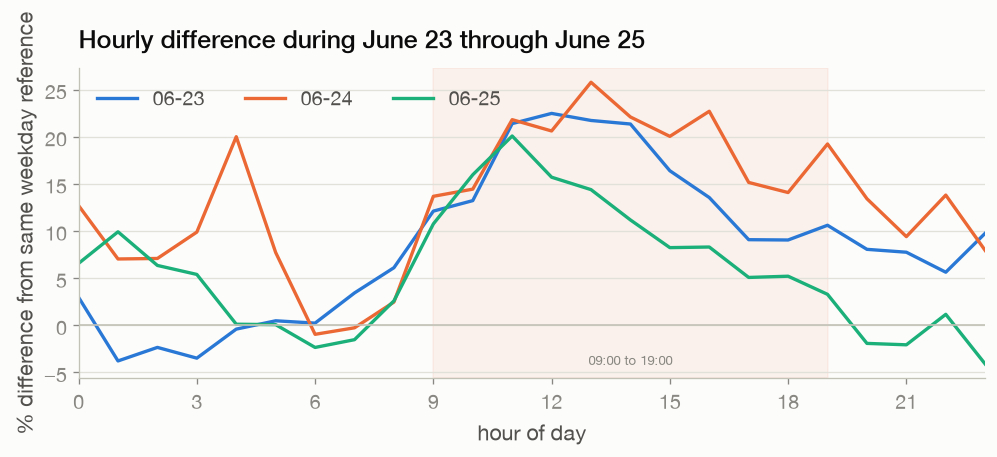

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 3.9))

for i, d in enumerate(EVENT_DATES):
    ax.plot(hourly_difference.index, hourly_difference[d],
            color=vizstyle.SERIES[i % 3], label=d[5:])
ax.axhline(0, color=vizstyle.BASELINE, linewidth=1.0)
ax.axvspan(9, 19, color=vizstyle.SERIES[1], alpha=0.07, zorder=0)
ax.annotate("09:00 to 19:00", (14, ax.get_ylim()[0] * 0.75), ha="center",
            fontsize=8, color=vizstyle.INK_MUTED)

ax.set_title("Hourly difference during June 23 through June 25")
ax.set_xlabel("hour of day"); ax.set_ylabel("% difference from same weekday reference")
ax.set_xticks(range(0, 24, 3)); ax.set_xlim(0, 23)
ax.legend(loc="upper left", ncol=3)
plt.tight_layout()

### Hourly pattern

The volume weighted citywide difference is 14.6% from 09:00 through 19:00, 5.3% from 20:00
through 23:00, 4.6% from 00:00 through 05:00, and 1.5% from 06:00 through 08:00. The largest
hourly differences, approximately 20% to 26%, occur from 11:00 through 14:00. The event profile
therefore differs from a uniform increase across the day.

The trip records do not identify the mechanism responsible for the increase. They measure
realized trip demand and cannot separate changes in latent demand, vehicle supply, matching,
acceptance, cancellations, or other concurrent conditions.

Later experiments use this hourly profile as one empirical event scenario. It represents one
documented heat event and does not estimate a general distribution of heat effects.

Citywide daily totals for June 8, June 19, and June 29 do not show differences of comparable
magnitude. This aggregate comparison does not evaluate localized or hourly changes associated
with events on those dates.

## 4. Borough level origin and destination balance

Notebook 01 reported destination shares conditional on pickup borough. This section reports the
origins of trips arriving in each borough and calculates net passenger trip flow as arrivals
minus departures.

Net passenger trip flow describes occupied trips recorded in the dataset. It excludes vehicle
movements without passengers and does not measure the number or final location of available
vehicles.

In [13]:
REAL = ("zp.Borough NOT IN ('Unknown','N/A','EWR') AND "
        "zd.Borough NOT IN ('Unknown','N/A','EWR')")

od = con.sql(f"""
SELECT zp.Borough AS o, zd.Borough AS d, count(*) AS n
FROM t JOIN z zp ON t.PULocationID = zp.LocationID
       JOIN z zd ON t.DOLocationID = zd.LocationID
WHERE {REAL} GROUP BY 1, 2
""").df()

order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
M = od.pivot(index="o", columns="d", values="n").reindex(index=order, columns=order).fillna(0)

col_pct = (100 * M / M.sum(axis=0)).round(1)
col_pct

d,Manhattan,Brooklyn,Queens,Bronx,Staten Island
o,,,,,
Manhattan,74.2,12.4,18.0,17.4,3.3
Brooklyn,9.3,76.7,13.7,1.4,6.6
Queens,10.0,9.9,66.1,3.7,1.3
Bronx,6.3,0.6,2.2,77.4,0.2
Staten Island,0.1,0.4,0.1,0.0,88.5


In [14]:
bal = pd.DataFrame({"departures": M.sum(axis=1), "arrivals": M.sum(axis=0)}).astype(int)
bal["net"] = bal.arrivals - bal.departures
bal["net % of departures"] = (100 * bal.net / bal.departures).round(1)
bal

,departures,arrivals,net,net % of departures
Manhattan,6600364,6367144,-233220,-3.5
Brooklyn,5353441,5353864,423,0.0
Queens,4153502,4377476,223974,5.4
Bronx,2383963,2393501,9538,0.4
Staten Island,304904,304189,-715,-0.2


### Monthly net passenger trip flow

| Borough | Net (trips/month) | As % of departures |
|---|---|---|
| Manhattan | −233,220 | −3.5% |
| Brooklyn | +423 | less than 0.1% |
| Queens | +223,974 | +5.4% |
| Bronx | +9,538 | +0.4% |
| Staten Island | −715 | −0.2% |

Brooklyn records 5,353,864 arrivals and 5,353,441 departures, a difference of 423 trips. This
difference is less than 0.1% of departures. Among the three largest borough markets, Brooklyn
therefore has the smallest absolute net passenger flow at the monthly level.

Manhattan records 233,220 fewer arrivals than departures, or 3.5% of departures. Queens records
223,974 more arrivals than departures, or 5.4%. These totals describe cross borough passenger
trips and do not isolate the contribution of individual destinations such as airports.

A monthly net value near zero can result from offsetting flows across hours and locations. It
therefore does not imply that repositioning is unnecessary. Section 6 estimates how directional
imbalance varies by hour.

## 5. Citywide screening of destination and temporal concentration

Notebook 01 selects Brooklyn as the service region based on pickup volume and within borough
trip retention. The citywide analysis below evaluates whether entropy provides useful variation
across taxi zones. It does not contribute to service region selection. The implemented Brooklyn
zoning uses geographic contiguity and centroid proximity rather than entropy.

Entropy summarizes how observations are distributed across categories. Lower values indicate
concentration in fewer categories, while higher values indicate a broader distribution. The
analysis includes citywide pickup zones with at least 1,000 recorded trips.

1. **Destination entropy** measures the distribution of dropoff zones for trips originating in
   each pickup zone. Higher values indicate that recorded trips end in a wider range of zones.
2. **Normalized temporal entropy** measures the distribution of pickups across 24 hours. A value
   of zero would place all pickups in one hour, while a value of one would distribute pickups
   uniformly across hours.

These measures describe concentration within a zone. They do not identify which pairs of zones
should be combined in a spatial aggregation.

In [15]:
ent = con.sql("""
WITH dpair AS (SELECT PULocationID AS id, DOLocationID AS d, count(*) AS n FROM t GROUP BY 1, 2),
     thr   AS (SELECT PULocationID AS id, hour(request_datetime) AS h, count(*) AS n FROM t GROUP BY 1, 2),
     tot   AS (SELECT PULocationID AS id, count(*) AS n FROM t GROUP BY 1)
SELECT tot.id, tot.n AS trips,
       (SELECT -sum((n::DOUBLE / tot.n) * log2(n::DOUBLE / tot.n)) FROM dpair WHERE dpair.id = tot.id) AS H_dest,
       (SELECT count(*) FROM dpair WHERE dpair.id = tot.id)                                           AS n_dest,
       (SELECT -sum((n::DOUBLE / tot.n) * log2(n::DOUBLE / tot.n)) FROM thr   WHERE thr.id   = tot.id) AS H_time
FROM tot WHERE tot.n >= 1000
""").df()

zl = con.sql('SELECT LocationID AS id, "Zone" AS zone_name, Borough AS boro FROM z').df()
ent = ent.merge(zl, on="id")
ent["H_time_norm"] = ent.H_time / np.log2(24)

print(f"{len(ent)} zones with at least 1,000 pickups")
print(f"H_dest spans {ent.H_dest.min():.2f} to {ent.H_dest.max():.2f} bits "
      f"(uniform over 263 zones would be {np.log2(263):.2f})")
print(f"H_time_norm spans {ent.H_time_norm.min():.3f} to {ent.H_time_norm.max():.3f}")

254 zones with at least 1,000 pickups
H_dest spans 3.79 to 6.70 bits (uniform over 263 zones would be 8.04)
H_time_norm spans 0.843 to 0.995


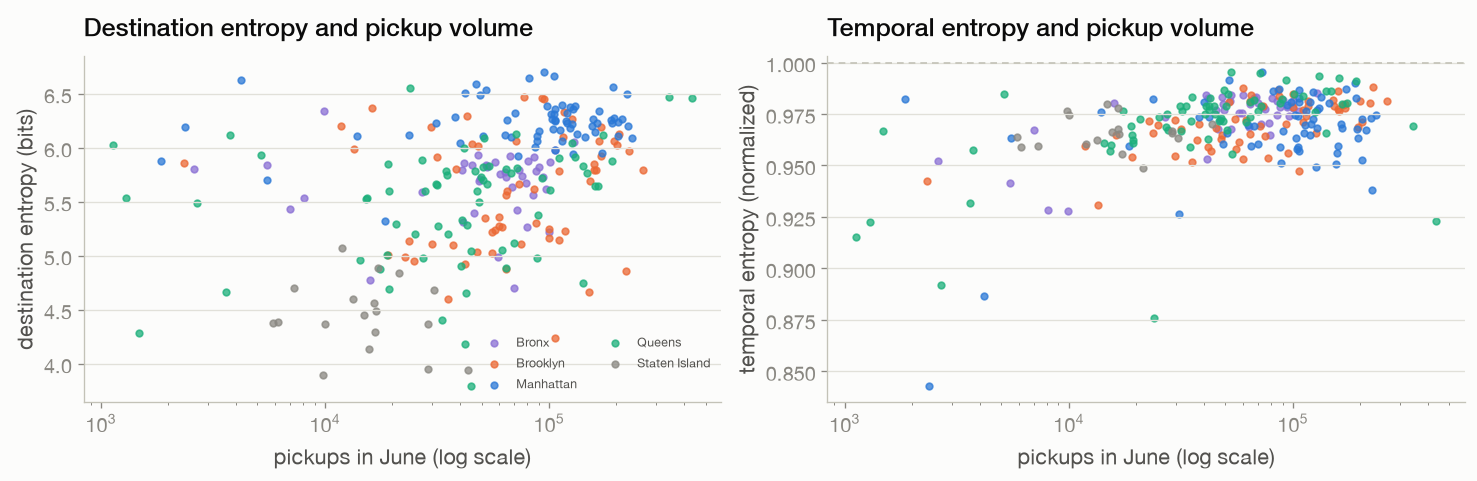

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
palette = {"Manhattan": vizstyle.SERIES[0], "Brooklyn": vizstyle.SERIES[1],
           "Queens": vizstyle.SERIES[2], "Bronx": "#8a6fd4", "Staten Island": vizstyle.INK_MUTED}

for b, g in ent.groupby("boro"):
    if b not in palette:
        continue
    axes[0].scatter(g.trips, g.H_dest, s=16, alpha=0.75, color=palette[b], label=b)
    axes[1].scatter(g.trips, g.H_time_norm, s=16, alpha=0.75, color=palette[b])

axes[0].set_ylabel("destination entropy (bits)")
axes[0].set_title("Destination entropy and pickup volume")
axes[0].legend(loc="lower right", fontsize=7.5, ncol=2)

axes[1].set_ylabel("temporal entropy (normalized)")
axes[1].set_title("Temporal entropy and pickup volume")
axes[1].axhline(1.0, color=vizstyle.BASELINE, linewidth=1.0, linestyle=(0, (4, 3)))

for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("pickups in June (log scale)")

plt.tight_layout()

In [17]:
print("LOWEST DESTINATION ENTROPY")
print(ent.nsmallest(8, "H_dest")[["zone_name", "boro", "trips", "H_dest", "n_dest"]]
        .round(2).to_string(index=False))
print()
print("HIGHEST destination entropy")
print(ent.nlargest(8, "H_dest")[["zone_name", "boro", "trips", "H_dest", "n_dest"]]
        .round(2).to_string(index=False))
print()
print("LOWEST NORMALIZED TEMPORAL ENTROPY")
print(ent.nsmallest(8, "H_time_norm")[["zone_name", "boro", "trips", "H_time_norm"]]
        .round(3).to_string(index=False))
print()
print("BOROUGH MEANS")
print(ent.groupby("boro")[["H_dest", "H_time_norm"]].mean().round(3).to_string())

LOWEST DESTINATION ENTROPY
                zone_name          boro  trips  H_dest  n_dest
             Far Rockaway        Queens  44805    3.79     239
   Charleston/Tottenville Staten Island   9811    3.89     164
Saint George/New Brighton Staten Island  43485    3.94     232
          Mariners Harbor Staten Island  28982    3.95     210
            Port Richmond Staten Island  15669    4.13     185
                 Rosedale        Queens  42100    4.18     234
             Borough Park      Brooklyn 106914    4.24     248
            Broad Channel        Queens   1481    4.28     131

HIGHEST destination entropy
                   zone_name      boro  trips  H_dest  n_dest
                    Kips Bay Manhattan  94531    6.70     257
             Lenox Hill East Manhattan 105511    6.67     256
     Two Bridges/Seward Park Manhattan  81653    6.65     255
             Randalls Island Manhattan   4205    6.62     208
                   Chinatown Manhattan  47408    6.59     254
     

### Findings

Destination entropy ranges from 3.79 to 6.70 bits across the 254 included zones. The unweighted
borough means are 6.23 bits for Manhattan, 5.67 for the Bronx, 5.59 for Brooklyn, 5.48 for
Queens, and 4.44 for Staten Island. Manhattan zones have higher destination entropy on average
in this sample.

Destination entropy is associated with pickup volume and the number of observed destinations.
The borough means do not adjust for these differences, so they do not establish an independent
borough effect. A comparison that controls for volume and destination coverage is required to
separate these relationships.

Normalized temporal entropy ranges from 0.843 to 0.995. Borough means range from 0.966 to 0.973,
which provides little separation at the borough level. The lowest values occur in several parks,
beaches, and airport zones. High temporal entropy indicates that trips are distributed across many
hours; it does not imply a constant hourly rate.

Destination entropy can describe the dispersion of trips from an origin zone, but it does not
specify a spatial merge. Pairwise trip flows and geographic continuity are required for that
purpose. Temporal entropy contributes little differentiation across most zones in this sample.

### Implications for zone design

Destination entropy asks how widely trips from one pickup zone are distributed across the city.
A lower value means that trips tend to end in a smaller set of destinations. A higher value means
that trip destinations are more dispersed. Temporal entropy asks whether pickups are concentrated
in a few hours or distributed across much of the day.

Manhattan has higher destination entropy on average, but this result is partly associated with
trip volume and the number of observed destinations. It is not sufficient evidence for choosing
one borough over another. Temporal entropy is similar across most zones and adds little information
for defining zone boundaries.

Because Brooklyn has already been selected, the borough averages are descriptive comparisons
rather than selection criteria. Evaluating entropy for Brooklyn zoning would require a separate
calculation on the Brooklyn trip population used by the input model. The current results indicate
that temporal entropy provides little separation, while destination entropy remains associated
with trip volume and destination coverage.

The implemented zoning groups contiguous Brooklyn taxi zones by centroid proximity. Pairwise trip
flows and entropy can be evaluated as diagnostics when comparing alternative zone maps, but they
do not determine the current boundaries.

## 6. Hourly passenger flow imbalance within Brooklyn

Monthly borough totals can conceal offsetting flows across locations and hours. This section
measures the hourly difference between passenger arrivals and departures across Brooklyn taxi
zones.

For each zone and hour, net passenger flow equals arrivals minus departures. The imbalance
statistic sums positive net flow across zones. Because the analysis includes trips with both
endpoints in Brooklyn, total arrivals equal total departures in each hour. The sum of arrival
surpluses therefore equals the sum of departure deficits.

Results are reported as an average weekday count and as a percentage of internal Brooklyn trips
in each hour. Higher values indicate that passenger trips redistribute more vehicles across taxi
zones during that hour.

Actual empty repositioning depends on the starting fleet distribution, inventory carried between
hours, travel times, and operating policy. The statistic measures passenger flow imbalance rather
than empty vehicle movements. Spatial aggregation also affects its magnitude because movements
within an aggregated zone no longer contribute to the calculation.

In [18]:
brooklyn_flow = con.sql("""
WITH w AS (
    SELECT t.*
    FROM t
    JOIN z zp ON t.PULocationID = zp.LocationID
    JOIN z zd ON t.DOLocationID = zd.LocationID
    WHERE dayofweek(request_datetime) BETWEEN 1 AND 5
      AND zp.Borough = 'Brooklyn'
      AND zd.Borough = 'Brooklyn'
),
weekday_count AS (
    SELECT count(DISTINCT CAST(request_datetime AS DATE)) AS n
    FROM w
),
dep AS (
    SELECT hour(request_datetime) AS h, PULocationID AS id, count(*) AS n
    FROM w
    GROUP BY 1, 2
),
arr AS (
    SELECT hour(request_datetime) AS h, DOLocationID AS id, count(*) AS n
    FROM w
    GROUP BY 1, 2
)
SELECT coalesce(dep.h, arr.h) AS h,
       coalesce(dep.id, arr.id) AS id,
       coalesce(dep.n, 0) / (SELECT n FROM weekday_count) AS dep,
       coalesce(arr.n, 0) / (SELECT n FROM weekday_count) AS arr
FROM dep
FULL OUTER JOIN arr ON dep.h = arr.h AND dep.id = arr.id
""").df()

brooklyn_flow["net"] = brooklyn_flow.arr - brooklyn_flow.dep

imbalance = brooklyn_flow.groupby("h").apply(lambda x: pd.Series({
    "internal_trips": x.dep.sum(),
    "imbalance": x.net.clip(lower=0).sum(),
}), include_groups=False)
imbalance["pct_of_trips"] = 100 * imbalance.imbalance / imbalance.internal_trips

print(f"weekday internal trips/day  {imbalance.internal_trips.sum():>10,.0f}")
print(f"sum of hourly imbalance     {imbalance.imbalance.sum():>10,.0f}"
      f"   ({100 * imbalance.imbalance.sum() / imbalance.internal_trips.sum():.1f}% of trips)")
print(f"highest relative imbalance  {imbalance.pct_of_trips.idxmax():>10d}:00"
      f"   ({imbalance.pct_of_trips.max():.1f}% of that hour's trips)")
print(f"highest absolute imbalance  {imbalance.imbalance.idxmax():>10d}:00"
      f"   ({imbalance.imbalance.max():,.0f} trip equivalents)")
print(f"lowest relative imbalance   {imbalance.pct_of_trips.idxmin():>10d}:00"
      f"   ({imbalance.pct_of_trips.min():.1f}%)")
imbalance.round(1)

weekday internal trips/day     129,658
sum of hourly imbalance          9,363   (7.2% of trips)
highest relative imbalance           6:00   (16.3% of that hour's trips)
highest absolute imbalance           8:00   (755 trip equivalents)
lowest relative imbalance           14:00   (2.7%)


,internal_trips,imbalance,pct_of_trips
h,,,
0,3896.4,522.7,13.4
1,2391.8,303.3,12.7
2,1607.3,217.2,13.5
3,1176.2,143.2,12.2
4,1183.0,149.4,12.6
5,1654.1,256.0,15.5
6,3228.3,526.7,16.3
7,5613.6,662.1,11.8
8,7128.5,754.6,10.6


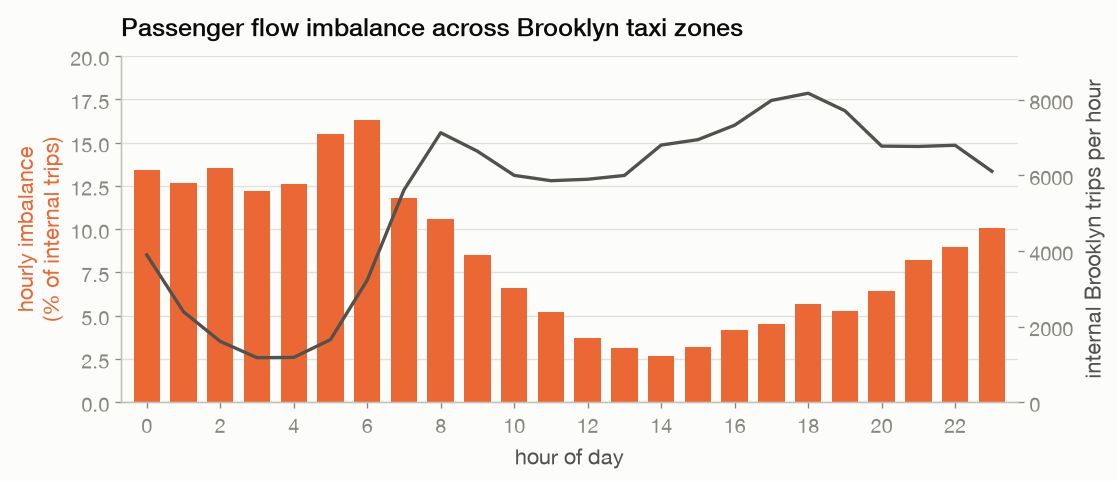

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.set_axisbelow(True)

ax.bar(imbalance.index, imbalance.pct_of_trips,
       color=vizstyle.SERIES[1], width=0.72, zorder=2)
ax.set_ylabel("hourly imbalance\n(% of internal trips)", color=vizstyle.SERIES[1])
ax.set_xlabel("hour of day")
ax.set_ylim(0, 20)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.7, 23.7)

ax2 = ax.twinx()
ax2.plot(imbalance.index, imbalance.internal_trips,
         color=vizstyle.INK_SECONDARY, linewidth=2.0, zorder=3)
ax2.set_ylabel("internal Brooklyn trips per hour", color=vizstyle.INK_SECONDARY)
ax2.set_ylim(0, imbalance.internal_trips.max() * 1.12)
ax2.grid(False)

ax.set_title("Passenger flow imbalance across Brooklyn taxi zones")
plt.tight_layout()

### Findings

Across Brooklyn's 61 taxi zones, the sum of hourly passenger flow imbalance is 9,045 trip
equivalents per weekday. This is 7.2% of the 125,496 weekday trips with both endpoints in
Brooklyn.

Relative imbalance is highest at 06:00, when the zone level surplus equals 17.2% of internal
trips during that hour. It declines to 2.4% at 14:00 and then increases through the late evening.
Absolute imbalance is highest at 08:00, at approximately 796 trip equivalents, because trip volume
is substantially higher than at 06:00.

The percentage and count describe different aspects of the pattern. The percentage measures the
spatial asymmetry of passenger flows within an hour. The count measures the scale of the resulting
change in vehicle distribution.

### Operational interpretation

Passenger trips redistribute vehicles most unevenly during the early morning. This pattern makes
service outcomes more sensitive to fleet placement and repositioning policy during those hours.
The trip records do not identify empty movements. A policy evaluation would represent vehicle
locations over time and measure empty trips, distance, and service outcomes under each policy.

The calculation uses the 61 Brooklyn taxi zones. Aggregation reduces the measured imbalance by
treating some movements as internal to a decision zone. Recalculation for each candidate zone map
quantifies the amount of imbalance absorbed by aggregation.

## 7. Summary

1. Daily trip volume varied less than hourly trip volume. In June, the maximum daily total was
   1.40 times the minimum and the coefficient of variation was approximately 8%. Mean weekday
   hourly volume varied by a factor of 5.7.
2. Hourly profiles differed across the week. Peak timing shifted from 08:00 on Monday through
   Wednesday to 19:00 on Thursday, 22:00 on Friday and Saturday, and 00:00 on Sunday. The fitted demand model represents these differences with four day types.
3. Recorded trip volume increased during the weekday portion of the June 2025 heat event. Relative
   to weekday references that exclude the event dates, daily volume increased by 10.4% on June 23,
   13.8% on June 24, and 5.8% on June 25. This result describes one event and does not establish a
   general causal effect of heat.
4. Brooklyn had near zero net passenger trip flow at the monthly borough level. This aggregate
   concealed substantial variation across hours and taxi zones.
5. Citywide destination entropy varied across zones but was associated with pickup volume and
   observed destination coverage. Temporal entropy provided little separation across boroughs.
   Neither measure is used in the implemented zoning.
6. Within Brooklyn, the sum of hourly passenger flow imbalance equaled 7.2% of internal weekday
   trips. Relative imbalance was highest at 06:00, while absolute imbalance was highest at 08:00.
   This statistic describes changes in vehicle distribution caused by passenger trips.

### Implications for model specification

The fitted demand model uses four day type profiles. Brooklyn remains the selected service region, and
later spatial aggregation uses geographic contiguity and centroid proximity. The June heat event
provides an observed disruption profile, subject to the limits of a single event. Passenger flow
imbalance provides a benchmark for evaluating spatial aggregation and modeled fleet behavior.
Empty movements, distance, and service outcomes would be measured in a policy evaluation.

All results describe recorded trips. Requests that did not produce a recorded trip remain
unobserved, so the analysis does not estimate latent demand.

## 8. Retained modeling tradeoffs

| Choice | Reason retained | Consequence |
|---|---|---|
| Represent the week with four day types | Pooling increases the observations available for each origin, destination, and hour rate while preserving the largest weekend differences. | Monday through Wednesday retain smaller weekday differences. Thursday and Friday remain materially different late at night; Notebook 05 quantifies the resulting bias. |
| Use the June heat event as an empirical disruption profile | The scenario is anchored in observed hourly demand during a documented event. | One event cannot identify a general heat response, and other concurrent conditions may explain part of the difference. |
| Exclude event dates from their own reference distribution | This prevents the event observations from inflating the mean and variance used to assess them. | Each weekday reference then contains only three or four June dates, so standardized differences are imprecise. |
| Measure passenger flow imbalance as a repositioning benchmark | The statistic is observable from the trip records and identifies when passenger trips redistribute vehicles across zones. | It is not empty travel. It omits starting inventory, movements between hours, vehicles entering or leaving service, and the response of a dispatch policy. |
| Use geographic continuity and centroid proximity for zoning | The procedure produces connected, reproducible spatial units without fitting boundaries to one demand sample. | The zones are not optimized for demand flows or within zone homogeneity. Aggregation also removes movements that occur inside a decision zone from the imbalance measure. |
| Use completed trips as the demand measure | The records provide broad spatial and temporal coverage. | Latent demand and changes in cancellations, acceptance, or supply remain unobserved, including during the heat event. |

The day type and zoning choices favor sample support and reproducibility. Their retained heterogeneity
is evaluated again when the demand and travel artifacts are constructed.